# 02 - VALIDATE DATASET

In [12]:
import zipfile
import torch
import matplotlib.pyplot as plt
import os
import tempfile
import torch
from torch.utils.data import TensorDataset, DataLoader
import zipfile
import os
import tempfile

In [33]:
def load_signals_from_zip(zip_path):
    signals_list, labels_list = [], []
    with zipfile.ZipFile(zip_path, 'r') as zipf:
        pt_files = [f for f in zipf.namelist() if f.endswith('.pt')]
        #with tempfile.TemporaryDirectory() as tmpdir:
        with tempfile.TemporaryDirectory(dir='/Volumes/KINGSTON/tmp') as tmpdir:
    # ...tu código...
            for pt_file in pt_files:
                zipf.extract(pt_file, tmpdir)
                pt_path = os.path.join(tmpdir, pt_file)
                data = torch.load(pt_path)
                signals_list.append(data['signals'])
                labels_list.append(data['labels'])
    signals = torch.cat(signals_list, dim=0)
    labels = torch.cat(labels_list, dim=0)
    return signals, labels

# Cargar los datos preparados desde los zip chunked
train_signals, train_labels = load_signals_from_zip('/Volumes/KINGSTON/TORCH/train_data_chunks.zip')
val_signals, val_labels = load_signals_from_zip('/Volumes/KINGSTON/TORCH/val_data_chunks.zip')
test_signals, test_labels = load_signals_from_zip('/Volumes/KINGSTON/TORCH/test_data_chunks.zip')

# Asegurarse que los labels sean float y binarios (0/1)
train_labels = train_labels.float().clamp(0, 1)
val_labels = val_labels.float().clamp(0, 1)
test_labels = test_labels.float().clamp(0, 1)

# Crear TensorDataset y DataLoader
train_dataset = TensorDataset(train_signals, train_labels)
val_dataset = TensorDataset(val_signals, val_labels)
test_dataset = TensorDataset(test_signals, test_labels)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print('Ejemplo de batch de señales:', next(iter(train_loader))[0].shape)
print('Ejemplo de batch de labels:', next(iter(train_loader))[1][:10])

Ejemplo de batch de señales: torch.Size([16, 12, 1000])
Ejemplo de batch de labels: tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])


In [34]:
# Comprobar la proporción de clases en train, val y test
import numpy as np
def print_class_proportion(labels, name):
    labels_np = labels.cpu().numpy() if hasattr(labels, 'cpu') else np.array(labels)
    total = len(labels_np)
    clase_0 = np.sum(labels_np == 0)
    clase_1 = np.sum(labels_np == 1)
    print(f'{name}:')
    print(f'  Clase 0: {clase_0} ({clase_0/total:.2%})')
    print(f'  Clase 1: {clase_1} ({clase_1/total:.2%})')
    print(f'  Total: {total}')

print_class_proportion(train_labels, 'TRAIN')
print_class_proportion(val_labels, 'VAL')
print_class_proportion(test_labels, 'TEST')

TRAIN:
  Clase 0: 15856 (95.12%)
  Clase 1: 814 (4.88%)
  Total: 16670
VAL:
  Clase 0: 4955 (95.11%)
  Clase 1: 255 (4.89%)
  Total: 5210
TEST:
  Clase 0: 3964 (95.11%)
  Clase 1: 204 (4.89%)
  Total: 4168


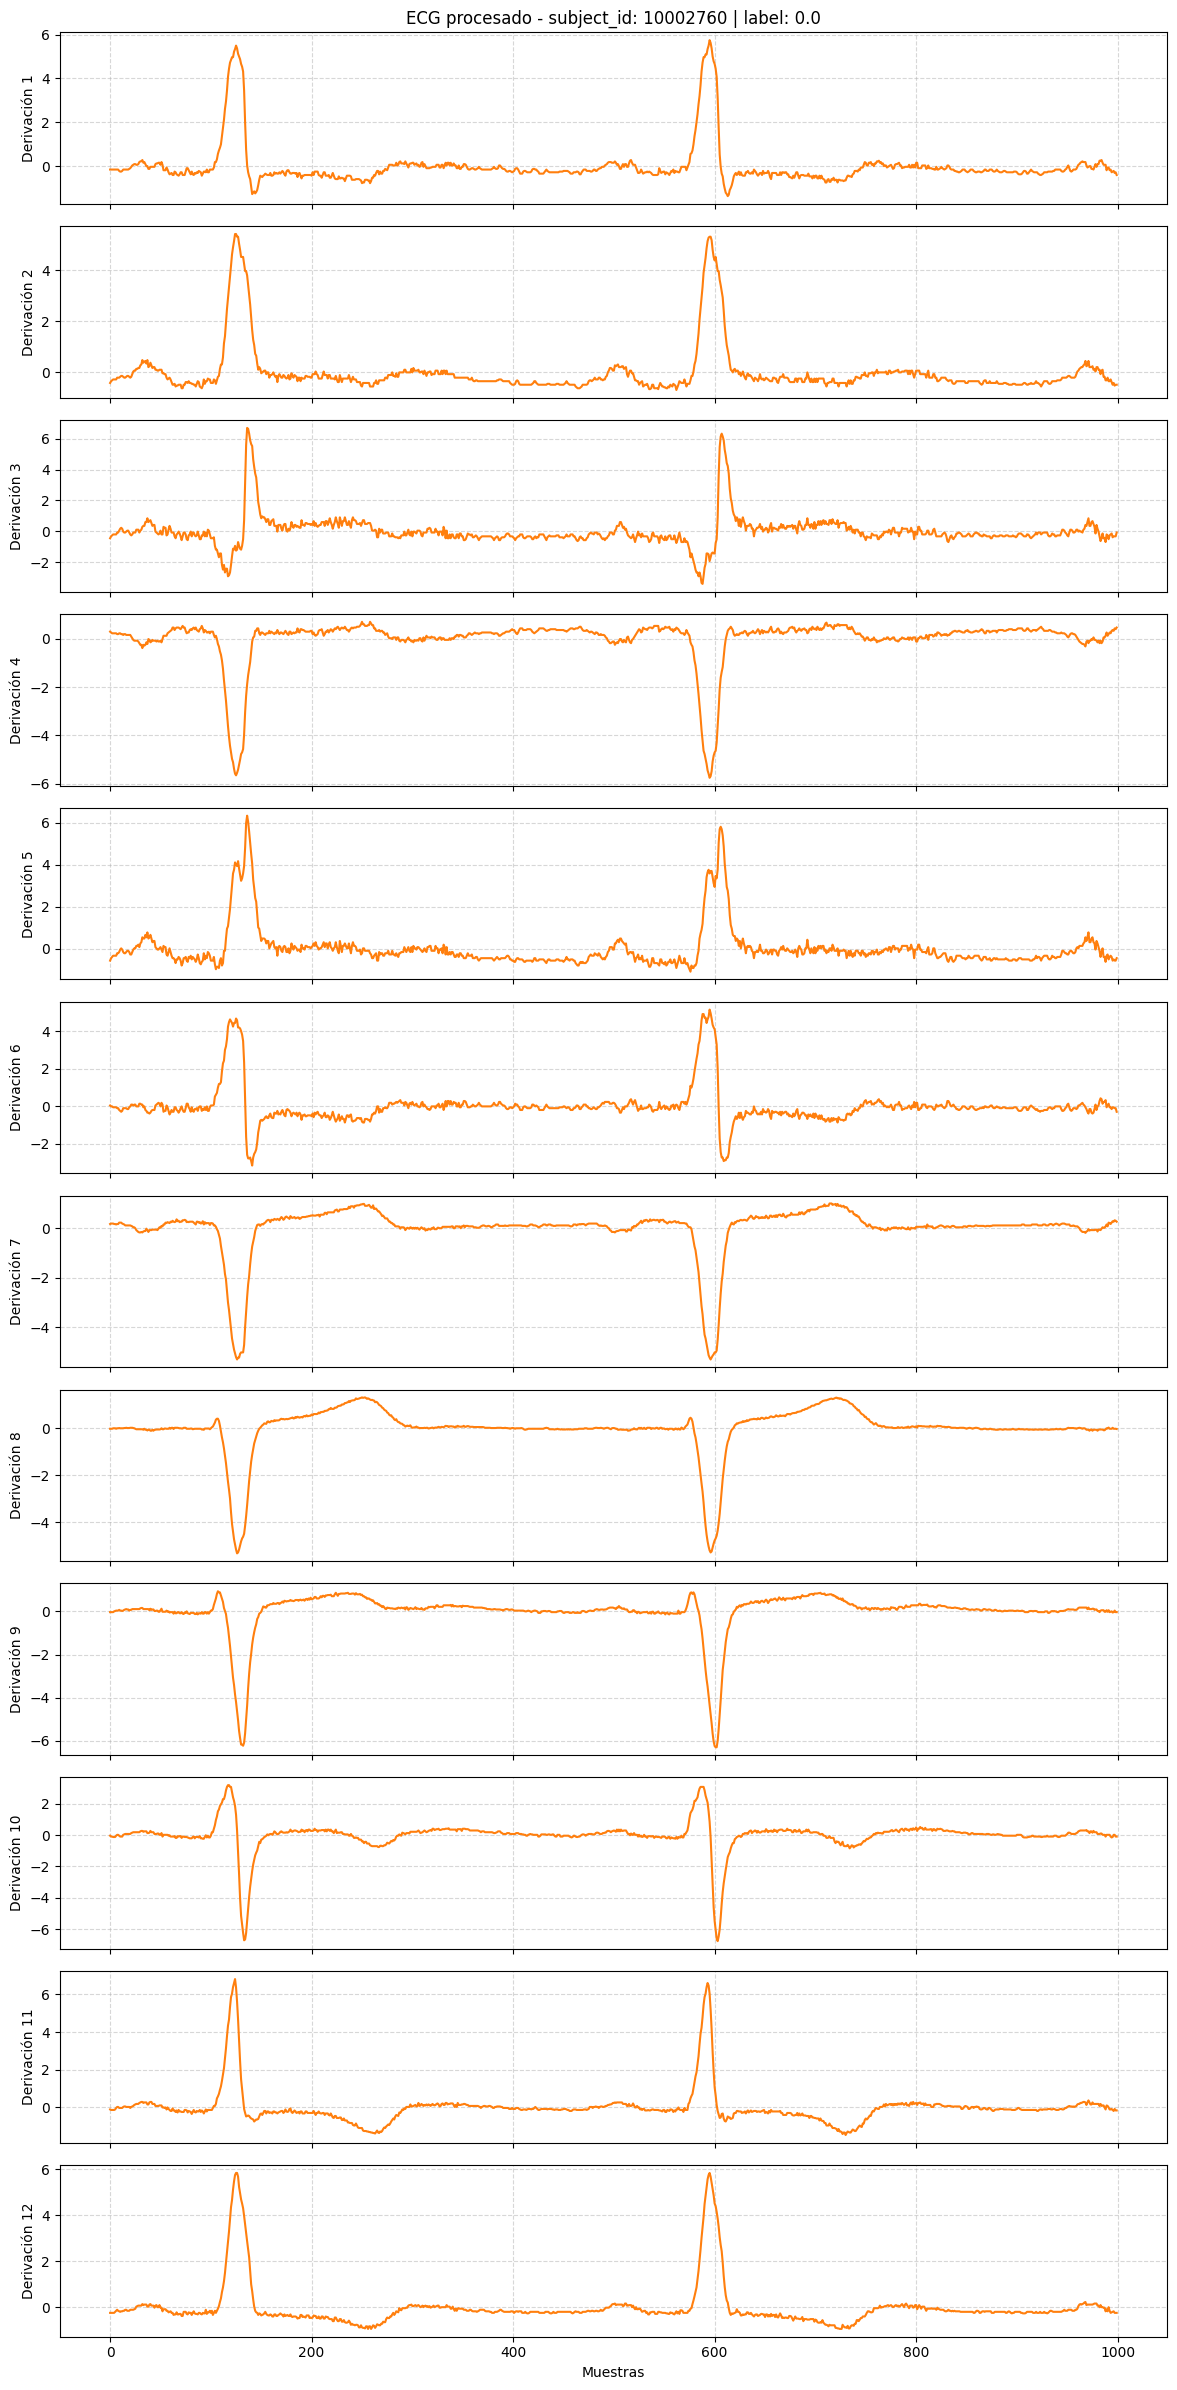

In [35]:
import torch
import pandas as pd
split_indices = torch.load('/Volumes/KINGSTON/TORCH/split_indices.pt')
if 'ecg_dataset' not in globals():
    ecg_dataset = pd.read_csv('aux_dataset/ecg_validated_dataset.csv')
def plot_ecg_by_subject(subject_id, window=None):
    import numpy as np
    df = ecg_dataset  # DataFrame cargado desde ecg_validated_dataset.csv
    indices = np.where(df['subject_id'] == subject_id)[0]
    if len(indices) == 0:
        print(f'Subject ID {subject_id} no encontrado en el dataset.')
        return
    idx = indices[0]
    train_indices = split_indices['/Volumes/KINGSTON/TORCH/train_data']
    if idx not in train_indices:
        print(f'Subject ID {subject_id} no está en el split de entrenamiento.')
        return
    split_idx = list(train_indices).index(idx)
    signal = train_signals[split_idx].numpy()
    label = train_labels[split_idx].item() if train_labels.ndim == 1 else train_labels[split_idx]
    n_leads = signal.shape[0]
    if window is not None and signal.shape[1] > window:
        signal = signal[:, :window]
    fig, axes = plt.subplots(n_leads, 1, figsize=(12, 2*n_leads), sharex=True)
    for i in range(n_leads):
        axes[i].plot(signal[i], color='C1')
        axes[i].set_ylabel(f'Derivación {i+1}')
        axes[i].grid(True, linestyle='--', alpha=0.5)
    axes[0].set_title(f'ECG procesado - subject_id: {subject_id} | label: {label}')
    axes[-1].set_xlabel('Muestras')
    plt.tight_layout()
    plt.show()

# Ejemplo de uso:
plot_ecg_by_subject(subject_id=10002760)  # Cambia el subject_id por el que desees visualizar